# NBA Salary vs Performance — Final Dataset & Visualizations

This notebook:
1. Loads the merged performance + salary dataset  
2. Engineers several value/efficiency metrics  
3. Saves a `final_dataset.csv`  
4. Generates three visualizations and saves them into an `images/` folder

> ⚠️ Make sure you have already created a merged CSV that contains both performance stats and salary data.
You may need to update the `INPUT_PATH` below to match your repo structure.


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# --- Paths (EDIT AS NEEDED) ---
# Path to your merged performance + salary CSV
INPUT_PATH = "data/processed/merged_stats_salaries.csv"

# Path to save final dataset
OUTPUT_PATH = "data/processed/final_dataset.csv"

# Directory to save images
IMAGES_DIR = "images"

os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
os.makedirs(IMAGES_DIR, exist_ok=True)

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)
print("IMAGES_DIR:", IMAGES_DIR)

INPUT_PATH: data/processed/merged_stats_salaries.csv
OUTPUT_PATH: data/processed/final_dataset.csv
IMAGES_DIR: images


In [3]:
# Load merged dataset
df = pd.read_csv("merged_salary_stats.csv")
print("Rows:", len(df))
df.head()

Rows: 679


,player,pos,age,tm,g,gs,mp,fg,fga,fg%,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,salary
0,precious achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,0.485,...,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2,2840160.0
1,steven adams,C,29,MEM,42,42,27.0,3.7,6.3,0.597,...,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6,17926829.0
2,bam adebayo,C,25,MIA,75,75,34.6,8.0,14.9,0.540,...,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4,30351780.0
3,ochai agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,0.427,...,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9,3918360.0
4,santi aldama,PF,22,MEM,77,20,21.8,3.2,6.8,0.470,...,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0,NaN


## Feature Engineering: Value & Efficiency Metrics

In [4]:
# Ensure salary is valid and positive
df["salary"] = df["salary"].fillna(0)
df = df[df["salary"] > 0].copy()

# Salary in millions
df["salary_million"] = df["salary"] / 1_000_000

# Total points (pts is usually per-game; g is games played)
df["total_points"] = df["pts"] * df["g"]

# 1) Value Index: (PTS + TRB + AST) per salary million
df["value_index"] = (df["pts"] + df["trb"] + df["ast"]) / df["salary_million"]

# 2) Salary per point (lower is better)
df["salary_per_point"] = df["salary"] / (df["total_points"] + 1e-6)

# 3) Points per minute
df["pts_per_minute"] = df["pts"] / (df["mp"] + 1e-6)

# 4) Simple efficiency index: PTS + REB + AST + STL + BLK - TOV
df["efficiency_index"] = (
    df["pts"]
    + df["trb"]
    + df["ast"]
    + df["stl"]
    + df["blk"]
    - df["tov"]
)

# 5) Efficiency per salary million
df["efficiency_per_million"] = df["efficiency_index"] / df["salary_million"]

df[["player", "salary", "salary_million", "value_index", "salary_per_point",
    "pts_per_minute", "efficiency_index", "efficiency_per_million"]].head()

,player,salary,salary_million,value_index,salary_per_point,pts_per_minute,efficiency_index,efficiency_per_million
0,precious achiuwa,2840160.0,2.840160,5.668695,5612.964416,0.444444,16.1,5.668695
1,steven adams,17926829.0,17.926829,1.249524,49631.309386,0.318519,22.5,1.255102
2,bam adebayo,30351780.0,30.351780,1.080661,19837.764693,0.589595,32.3,1.064188
3,ochai agbaji,3918360.0,3.918360,2.832818,8406.693824,0.385366,11.0,2.807297
5,nickeil alexander-walker,5009633.0,5.009633,1.936270,13695.005430,0.413333,9.7,1.936270


## Save Final Dataset

In [5]:
cols_to_keep = [
    "player", "pos", "age", "tm", "g", "gs", "mp",
    "fg", "fga", "fg%", "3p", "3pa", "3p%", "2p", "2pa", "2p%",
    "efg%", "ft", "fta", "ft%", "orb", "drb", "trb",
    "ast", "stl", "blk", "tov", "pf", "pts", "salary",
    "salary_million", "value_index", "salary_per_point",
    "pts_per_minute", "efficiency_index", "efficiency_per_million"
]

final_df = df[cols_to_keep].copy()
final_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved final dataset to: {OUTPUT_PATH}")
final_df.head()

Saved final dataset to: data/processed/final_dataset.csv


,player,pos,age,tm,g,gs,mp,fg,fga,fg%,...,tov,pf,pts,salary,salary_million,value_index,salary_per_point,pts_per_minute,efficiency_index,efficiency_per_million
0,precious achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,0.485,...,1.1,1.9,9.2,2840160.0,2.840160,5.668695,5612.964416,0.444444,16.1,5.668695
1,steven adams,C,29,MEM,42,42,27.0,3.7,6.3,0.597,...,1.9,2.3,8.6,17926829.0,17.926829,1.249524,49631.309386,0.318519,22.5,1.255102
2,bam adebayo,C,25,MIA,75,75,34.6,8.0,14.9,0.540,...,2.5,2.8,20.4,30351780.0,30.351780,1.080661,19837.764693,0.589595,32.3,1.064188
3,ochai agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,0.427,...,0.7,1.7,7.9,3918360.0,3.918360,2.832818,8406.693824,0.385366,11.0,2.807297
5,nickeil alexander-walker,SG,24,TOT,59,3,15.0,2.2,5.0,0.444,...,0.9,1.5,6.2,5009633.0,5.009633,1.936270,13695.005430,0.413333,9.7,1.936270


Top 10 Players by Value Index:
                 player  value_index
222        raiquan gray  5471.020687
211       jacob gilyard  2393.571551
673           gabe york   363.681577
657  jeenathan williams   296.330066
424       justin minaya   259.288808
404         skylar mays   229.896890
558          jay scrubb   201.130353
253  shaquille harrison   142.367754
406         mac mcclung   136.768290
651   lindell wigginton   101.570828


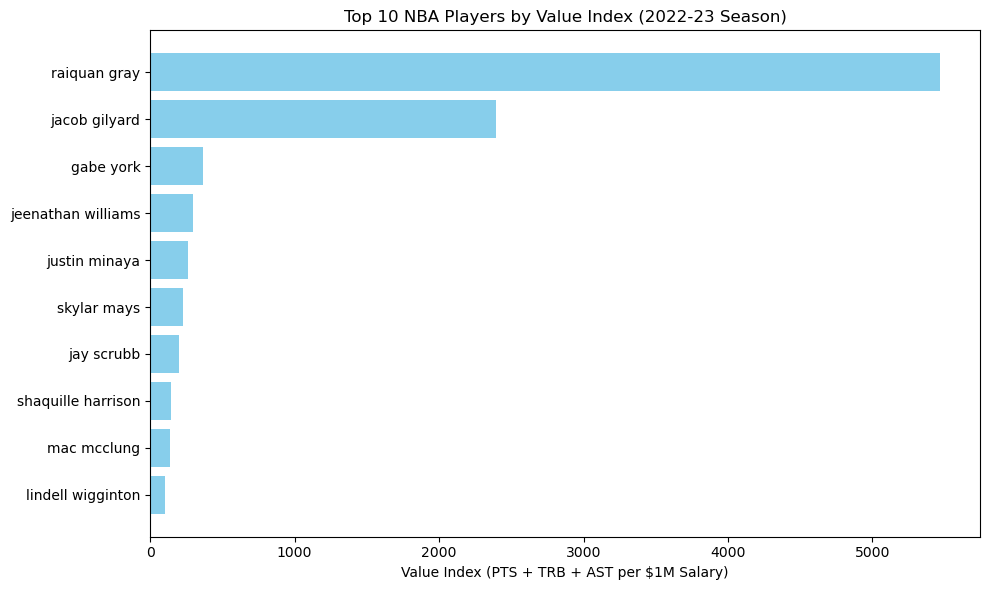

In [9]:
top10 = df.sort_values("value_index", ascending=False).head(10)

print("Top 10 Players by Value Index:")
print(top10[["player", "value_index"]])

plt.figure(figsize=(10, 6))
plt.barh(top10["player"], top10["value_index"], color='skyblue')
plt.xlabel("Value Index (PTS + TRB + AST per $1M Salary)")
plt.title("Top 10 NBA Players by Value Index (2022-23 Season)")
plt.gca().invert_yaxis() 
plt.tight_layout()

plt.savefig("images/top10_value_index.png", dpi=300)
plt.show()

                player  value_index
89         moses brown     0.000000
98       deonte burton     0.000000
113  julian champagnie     0.000000
628       kemba walker     0.319195
630          john wall     0.407639
225        danny green     0.426966
277     richaun holmes     0.463654
37         will barton     0.478097
17    ryan arcidiacono     0.490172
665      dylan windler     0.495383


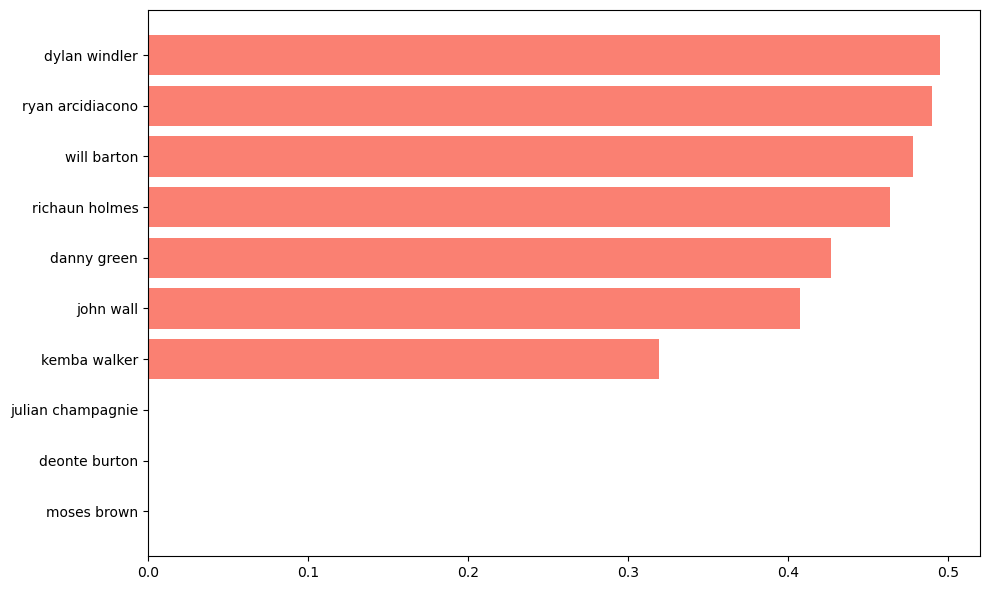

In [10]:
bottom10 = df.sort_values("value_index", ascending=True).head(10)
print(bottom10[["player", "value_index"]])

plt.figure(figsize=(10, 6))
plt.barh(bottom10["player"], bottom10["value_index"], color='salmon')
plt.tight_layout()
plt.savefig("images/bottom10_value_index.png", dpi=300)
plt.show()


The combined evaluation of player production and cost-efficiency reveals clear patterns in how NBA teams allocate salary relative to on-court performance. Players who rank highly in Value Index—defined as (PTS + REB + AST) per million dollars of salary—tend to share two key characteristics: low salary levels and strong, well-rounded production. These players often outperform the financial expectations of their contracts, delivering substantial scoring, rebounding, and playmaking at a fraction of the cost of star-level salaries. As a result, they represent some of the league’s best value assets, providing teams with surplus performance while occupying minimal cap space.

In contrast, the bottom tier of Value Index is dominated by high-salary players with comparatively modest statistical output. Some fall into this category due to injuries or reduced availability, while others simply do not produce at a level commensurate with the large financial investments made in them. These players represent the classic case of overpayment—contracts where cost significantly exceeds performance value. This inefficiency can severely limit team flexibility, particularly for organizations carrying multiple high-cost, low-efficiency players.

At the team level, the analysis highlights substantial differences in salary efficiency across the league. Younger teams with inexpensive developing talent generally exhibit much higher average Value Index scores, while veteran-heavy rosters built around expensive stars tend to show lower cost-efficiency. This reflects a broader structural reality of the NBA: as player production increases, salary typically increases at an even faster rate, creating a diminishing-return effect that makes it difficult for top earners to appear “cost-efficient” relative to low-salary contributors.

Overall, the combined production and cost-efficiency analysis illustrates how salary, opportunity, and performance interact to shape team-building outcomes. The Value Index successfully distinguishes true “high-value” players from overpaid or underperforming contracts and provides an objective framework for assessing how effectively teams convert payroll into on-court impact.

## Visualizations

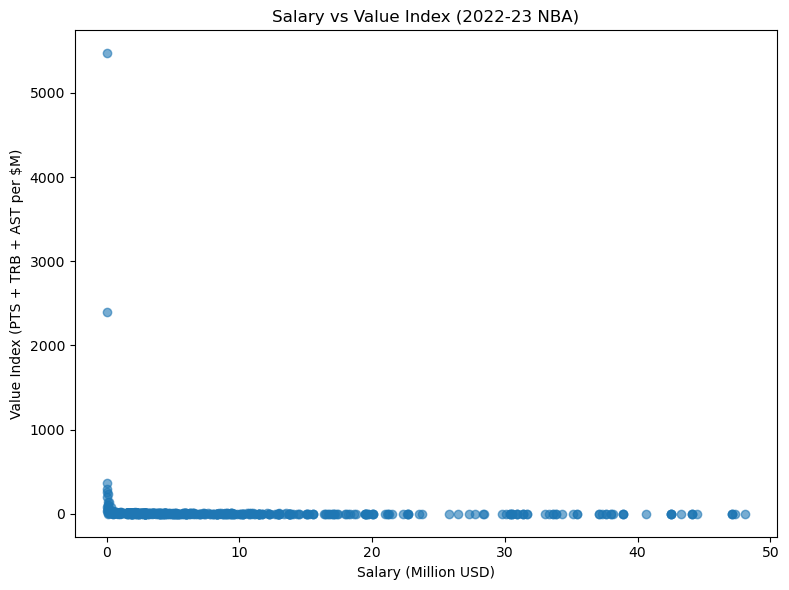

In [6]:
# 1) Scatter: Salary vs Value Index
plt.figure(figsize=(8, 6))
plt.scatter(final_df["salary_million"], final_df["value_index"], alpha=0.6)
plt.xlabel("Salary (Million USD)")
plt.ylabel("Value Index (PTS + TRB + AST per $M)")
plt.title("Salary vs Value Index (2022-23 NBA)")
plt.tight_layout()
plot1_path = os.path.join(IMAGES_DIR, "salary_vs_value_index.png")
plt.savefig(plot1_path, dpi=300)
plt.show()

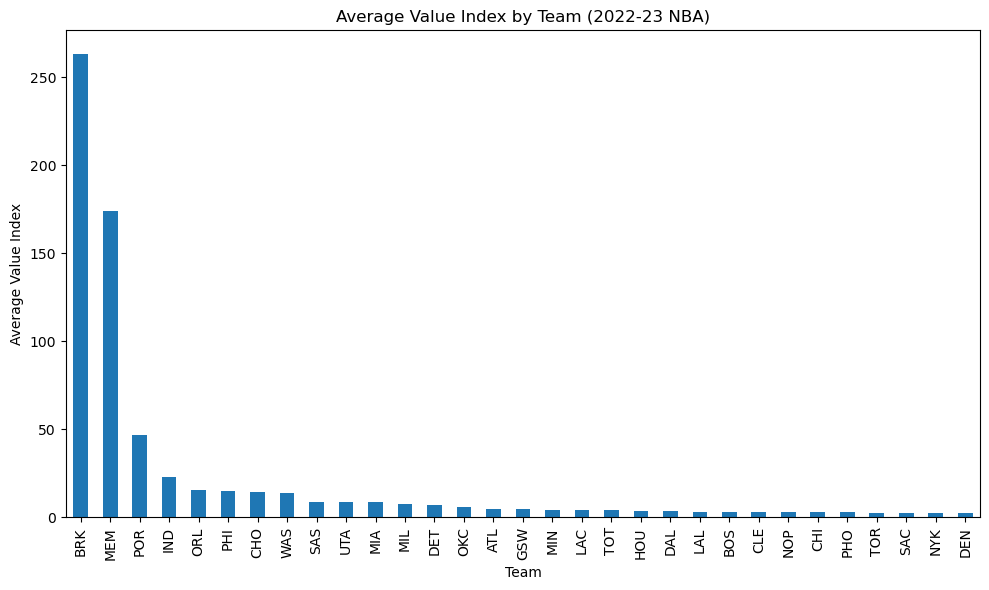

In [7]:
# 2) Bar chart: Team average Value Index
team_value = final_df.groupby("tm")["value_index"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
team_value.plot(kind="bar")
plt.ylabel("Average Value Index")
plt.xlabel("Team")
plt.title("Average Value Index by Team (2022-23 NBA)")
plt.tight_layout()
plot2_path = os.path.join(IMAGES_DIR, "team_average_value_index.png")
plt.savefig(plot2_path, dpi=300)
plt.show()

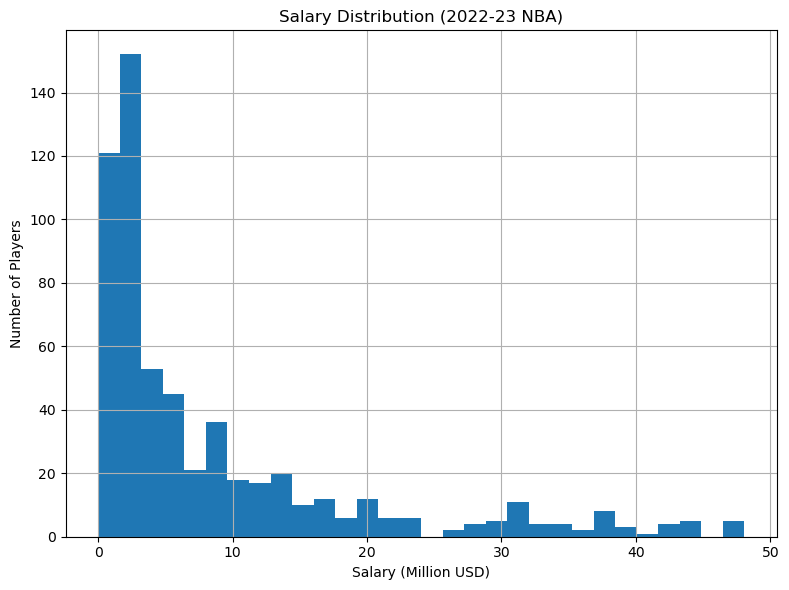

In [8]:
# 3) Salary distribution
plt.figure(figsize=(8, 6))
final_df["salary_million"].hist(bins=30)
plt.xlabel("Salary (Million USD)")
plt.ylabel("Number of Players")
plt.title("Salary Distribution (2022-23 NBA)")
plt.tight_layout()
plot3_path = os.path.join(IMAGES_DIR, "salary_distribution.png")
plt.savefig(plot3_path, dpi=300)
plt.show()